# Reconocimiento Facial con KNN + Haar Cascade
### Módulo 3 · Aprendizaje Automático

**Flujo completo:**

```
Carpeta Rostros/
  ├── persona_1.jpg  ← entrenamiento (_1)   →  x_train, y_train
  └── persona_2.jpg  ← prueba       (_2)   →  x_test,  y_test
```

| Sección | Qué hace |
|---------|----------|
| 1 | Imports + ruta |
| 2 | Funciones reutilizables |
| 3 | Carga automática con glob |
| 4 | Entrenamiento KNN |
| 5 | Prueba con 10+ imágenes + tabla |


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob        # para buscar archivos con patrones (*.jpeg, *_1.*, etc.)
import os          # para manipular rutas y nombres de archivos

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics   import accuracy_score

# ── Ruta de las imágenes ────────────────────────────────────────────────
# Ajusta esta ruta a donde tengas la carpeta Rostros en tu equipo
# El os.sep al final asegura que termine en / (Linux) o \ (Windows)
RUTA = os.path.join('..', 'Material', 'Rostros') + os.sep
# Si necesitas ruta absoluta, reemplaza por:
# RUTA = r'C:\Users\Diplomado-RNA\Modulo-3\Material\Rostros\\'

# ── Tamaño estándar de rostro ────────────────────────────────────────────
# Todas las imágenes recortadas se escalan a este tamaño antes de
# meterlas al clasificador. Es un hiperparámetro: puedes probar 100, 200, 694
TAMANO = 694   # 694x694 px → vector de 694*694*3 = 1,428,876 valores

print(f"Ruta configurada: {RUTA}")
print(f"Tamaño de rostro: {TAMANO}x{TAMANO} px")
print(f"Imports listos ✅")

Ruta configurada: ..\Material\Rostros\
Tamaño de rostro: 694x694 px
Imports listos ✅


---
## Sección 2 — Funciones reutilizables

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Cargar el modelo Haar Cascade
# ═══════════════════════════════════════════════════════════════
# Haar Cascade = detector de rostros preentrenado que viene con OpenCV
# No es KNN — es el detector que nos dice DÓNDE está la cara en la imagen
# KNN viene después: clasifica A QUIÉN pertenece esa cara

# cv2.data.haarcascades apunta a la carpeta donde OpenCV instala sus modelos
# haarcascade_frontalface_alt.xml → bueno para fotos frontales
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml"
)

print("Haar Cascade cargado ✅")
print(f"Cascades disponibles en OpenCV:")
for f in sorted(os.listdir(cv2.data.haarcascades)):
    if f.endswith('.xml'):
        print(f"  • {f}")

Haar Cascade cargado ✅
Cascades disponibles en OpenCV:
  • haarcascade_eye.xml
  • haarcascade_eye_tree_eyeglasses.xml
  • haarcascade_frontalcatface.xml
  • haarcascade_frontalcatface_extended.xml
  • haarcascade_frontalface_alt.xml
  • haarcascade_frontalface_alt2.xml
  • haarcascade_frontalface_alt_tree.xml
  • haarcascade_frontalface_default.xml
  • haarcascade_fullbody.xml
  • haarcascade_lefteye_2splits.xml
  • haarcascade_license_plate_rus_16stages.xml
  • haarcascade_lowerbody.xml
  • haarcascade_profileface.xml
  • haarcascade_righteye_2splits.xml
  • haarcascade_russian_plate_number.xml
  • haarcascade_smile.xml
  • haarcascade_upperbody.xml


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — detectar_y_recortar()
# ═══════════════════════════════════════════════════════════════

def detectar_y_recortar(ruta_imagen, escala=1.3, vecinos=3, tamano=TAMANO):
    """
    Lee una imagen, detecta el primer rostro con Haar Cascade y lo recorta.

    Parámetros:
        ruta_imagen → ruta completa al archivo de imagen
        escala      → scaleFactor de detectMultiScale (cuánto se reduce la imagen
                      en cada escala). 1.1 = más detecciones, más lento.
                      1.3 = más rápido, puede perder caras pequeñas.
        vecinos     → minNeighbors: cuántos rectángulos vecinos se necesitan para
                      confirmar una detección. Más alto = menos falsos positivos.
        tamano      → tamaño al que se redimensiona el rostro detectado

    Regresa:
        rostro_array → array numpy del rostro recortado (tamano x tamano x 3)
                       o None si no se detectó ningún rostro
        info         → dict con metadatos útiles de la imagen
    """
    # ── Lectura de la imagen ──────────────────────────────────────────────
    # cv2.imread lee en formato BGR (azul-verde-rojo)
    # plt.imshow espera RGB → por eso convertimos con cvtColor
    img = cv2.imread(ruta_imagen)
    if img is None:
        print(f"  ⚠️  No se pudo leer: {ruta_imagen}")
        return None, {}

    # Conversión de color
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Versión en escala de grises para el detector
    # (Haar Cascade trabaja sobre imagen gris, no color)
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── Metadatos de la imagen ────────────────────────────────────────────
    # Estos son datos que podemos extraer de la imagen ANTES de la detección
    alto, ancho = img.shape[:2]
    brillo      = round(float(np.mean(img_gris)), 1)   # 0=negro, 255=blanco
    contraste   = round(float(np.std(img_gris)), 1)    # qué tan variados son los píxeles

    # ── Detección de rostros ──────────────────────────────────────────────
    # detectMultiScale busca la cara en múltiples escalas de la imagen
    # Devuelve un array de rectángulos: [[x, y, ancho, alto], ...]
    rostros = face_cascade.detectMultiScale(img_rgb, escala, vecinos)

    info = {
        'archivo':      os.path.basename(ruta_imagen),
        'dimensiones':  f"{ancho}×{alto}",
        'brillo':       brillo,
        'contraste':    contraste,
        'n_rostros':    len(rostros),
        'detectado':    len(rostros) > 0
    }

    if len(rostros) == 0:
        return None, info

    # Tomamos el primer rostro detectado (el más prominente)
    # rostros[0] = [x, y, w, h] = coordenadas del rectángulo
    x, y, w, h = rostros[0]
    info['rect'] = (x, y, w, h)     # guardamos el rectángulo en info

    # ── Recorte y redimensionado ──────────────────────────────────────────
    # img_rgb[y:y+h, x:x+w, :] = recorte rectangular de la imagen
    # Los : al final significa "todos los canales de color" (R, G, B)
    rostro_recortado = img_rgb[y:y+h, x:x+w, :]

    # Redimensionamos a tamaño estándar para que todos los vectores
    # del clasificador tengan la misma longitud
    rostro_array = cv2.resize(rostro_recortado, (tamano, tamano))
    
   

    return rostro_array, info

# ═══════════════════════════════════════════════════════════════
# CELDA EXTRA — Detectar características: lentes y sonrisa
# ═══════════════════════════════════════════════════════════════

# Cargamos los detectores auxiliares — ya vienen con OpenCV

cascade_ojos_lentes = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_eye_tree_eyeglasses.xml"
)
cascade_ojos = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_eye.xml"
)
cascade_sonrisa = cv2.CascadeClassifier(
cv2.data.haarcascades + "haarcascade_smile.xml"
)


def analizar_caracteristicas(ruta_imagen):
    """
    Detecta características faciales en una imagen:
    lentes, ojos y sonrisa.
    
    Estos detectores trabajan DENTRO del rostro ya detectado,
    no en la imagen completa → menos falsos positivos.
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return {}
    
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Detectar el rostro primero
    rostros = face_cascade.detectMultiScale(img_rgb, 1.1, 2)
    if len(rostros) == 0:
        return {'detectado': False}
    
    x, y, w, h = rostros[0]
    
    # Recortamos SOLO la región del rostro para buscar dentro
    rostro_gris = img_gris[y:y+h, x:x+w]
    
    # 2. Buscar ojos con lentes DENTRO del rostro
    # scaleFactor=1.1, minNeighbors=5 para reducir falsos positivos
    ojos_con_lentes = cascade_ojos_lentes.detectMultiScale(
        rostro_gris, 1.1, 5
    )
    
    # 3. Buscar ojos normales (sin lentes)
    ojos_normales = cascade_ojos.detectMultiScale(
        rostro_gris, 1.1, 5
    )
    
    # 4. Buscar sonrisa — solo en la mitad inferior del rostro
    # (así evitamos que detecte la nariz como sonrisa)
    mitad_inferior = rostro_gris[h//2:, :]
    sonrisas = cascade_sonrisa.detectMultiScale(
        mitad_inferior, 1.7, 20   # minNeighbors alto para menos falsos positivos
    )
    
    tiene_lentes = len(ojos_con_lentes) > 0
    tiene_sonrisa = len(sonrisas) > 0
    
    return {
        'detectado':    True,
        'lentes':       '🕶️ Sí' if tiene_lentes else 'No',
        'sonrisa':      '😊 Sí' if tiene_sonrisa else 'No',
        'n_ojos':       len(ojos_normales),
    }


print("detectar_y_recortar() definida ✅")
print("analizar_caracteristicas() definida ✅")

detectar_y_recortar() definida ✅
analizar_caracteristicas() definida ✅


### Cambiamos la forma de extraer los datos Ya que genera un error al momento de ingresarlo al array, Dejo este bloque igual como referencia

Ya que dgr_2.jpg muestra Real: eggs_1 — eso está mal, debería ser dgr_1. Eso pasa porque cuando fybr_1 no se detecta en entrenamiento, los índices de test y train quedan desincronizados.

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — cargar_dataset()
# ═══════════════════════════════════════════════════════════════

def cargar_dataset(ruta, sufijo='_1', extensiones=('jpg','jpeg','JPG','JPEG','png')):
    """
    Carga automáticamente todas las imágenes con el sufijo dado.
    En lugar de listar los archivos a mano, usamos glob para descubrir
    todos los archivos que terminen en _1.ext o _2.ext.

    En la carpeta del diplomado (../Material/Rostros) tiene esta estructura:
        persona_1.jpg → entrenamiento (sufijo='_1')
        persona_2.jpg → prueba        (sufijo='_2')

    El índice de etiqueta (0, 1, 2...) se asigna en el orden en que
    aparecen los archivos. El diccionario etiqueta_a_nombre guarda
    la correspondencia entre índice y nombre.

    Regresa:
        X          → array (N, tamano*tamano*3) con los vectores de rostros
        y          → array (N,) con las etiquetas numéricas
        nombres    → lista de nombres de archivo en orden de etiqueta
        infos      → lista de dicts con metadatos de cada imagen
    """
    # ── Buscar todos los archivos con el sufijo ────────────────────────────
    archivos = []
    for ext in extensiones:
        # glob.glob busca con comodines: * = cualquier texto
        # Ejemplo: '../Rostros/*_1.jpeg' encuentra 'fybr_1.jpeg', 'jjar_1.jpeg', etc.
        patron = ruta + f'*{sufijo}.{ext}'
        archivos.extend(glob.glob(patron))

    archivos = sorted(set(os.path.normcase(a) for a in archivos))   # orden alfabético para reproducibilidad y eliminar duplicados (en Windows las mayúsculas no importan)

    if not archivos:
        print(f"  ⚠️  No se encontraron imágenes con sufijo '{sufijo}' en {ruta}")
        print(f"  Extensiones buscadas: {extensiones}")
        return None, None, [], []

    print(f"  Encontradas {len(archivos)} imágenes con sufijo '{sufijo}':")

    X, y, nombres, infos = [], [], [], []

    for etiqueta, archivo in enumerate(archivos):
        nombre = os.path.basename(archivo)
        rostro, info = detectar_y_recortar(archivo)

        if rostro is not None:
            # Aplanamos el rostro: de (694,694,3) → (30000,)
            # Esto convierte la imagen en un vector 1D que el clasificador puede usar
            X.append(rostro.flatten())
            y.append(etiqueta)
            nombres.append(nombre)
            infos.append(info)
            estado = '✅'
        else:
            # Si no se detectó cara, igual guardamos el nombre pero sin datos
            nombres.append(nombre)
            infos.append(info)
            estado = '❌ sin rostro'

        print(f"    [{etiqueta:2d}] {nombre:<25} {estado}  "
              f"({info.get('dimensiones','?')}, brillo={info.get('brillo','?')})")

    X = np.array(X)
    y = np.array(y)

    print(f"\n  Dataset listo: {len(X)} imágenes procesadas")
    print(f"  Shape X: {X.shape}  |  Shape y: {y.shape}")
    return X, y, nombres, infos


print("cargar_dataset() definida ✅")

cargar_dataset() definida ✅


---
### Hacemos el grid a las imagenes

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — mostrar_gri() + mostrar_deteccion()
# ═══════════════════════════════════════════════════════════════

def mostrar_grilla(X, nombres, titulo='Dataset', cols=5, tamano=TAMANO):
    """
    Muestra todas las imágenes del dataset en una cuadrícula.
    Útil para verificar visualmente que todas las caras se detectaron bien.
    """
    n = len(X)
    if n == 0:
        print("No hay imágenes para mostrar")
        return

    filas = (n + cols - 1) // cols   # redondeo hacia arriba

    fig, axes = plt.subplots(filas, cols, figsize=(cols * 2, filas * 2.2))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # axes puede ser 1D o 2D dependiendo de filas/cols → siempre aplanamos
    axes_flat = np.array(axes).flatten()

    for i, (img_vec, nombre) in enumerate(zip(X, nombres)):
        img = img_vec.reshape(tamano, tamano, 3)  # reconstruimos la imagen del vector
        axes_flat[i].imshow(img)
        # Nombre corto: quita la extensión y el sufijo _1/_2
        nombre_corto = os.path.splitext(nombre)[0]  # sin .jpeg
        axes_flat[i].set_title(nombre_corto, fontsize=7, pad=2)
        axes_flat[i].axis('off')

    # Ocultamos los ejes vacíos que sobren
    for j in range(i+1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()


def mostrar_deteccion(ruta_imagen, etiqueta_pred=None, etiqueta_real=None):
    """
    Muestra una imagen con el rectángulo del rostro detectado dibujado.
    El rectángulo se dibuja usando las coordenadas del array de detección,
    NO a mano — así funciona para cualquier imagen.
    """
    img = cv2.imread(ruta_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_copia = np.copy(img_rgb)   # copiamos para no modificar el original

    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rostros = face_cascade.detectMultiScale(img_rgb, 1.3, 3)

    color_rect = (0, 255, 0)    # verde = correcto
    if etiqueta_pred is not None and etiqueta_real is not None:
        if etiqueta_pred != etiqueta_real:
            color_rect = (255, 0, 0)  # rojo = incorrecto

    # ── El rectángulo viene del ARRAY, no a mano ──────────────────────────
    # rostros es un array numpy: cada fila es [x, y, w, h]
    # Iteramos sobre todas las detecciones (puede haber más de una cara)
    for (x, y, w, h) in rostros:
        # cv2.rectangle(imagen, esquina_superior_izq, esquina_inferior_der, color, grosor)
        cv2.rectangle(img_copia, (x, y), (x+w, y+h), color_rect, 3)
        # Opcional: texto encima del rectángulo
        if etiqueta_pred is not None:
            cv2.putText(img_copia, str(etiqueta_pred),
                       (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_rect, 2)

    plt.imshow(img_copia)
    plt.title(os.path.basename(ruta_imagen))
    plt.axis('off')
    plt.show()


print("mostrar_grilla() y mostrar_deteccion() definidas ✅")

mostrar_grilla() y mostrar_deteccion() definidas ✅


---
### Nuevo bloque v2


In [17]:
def extraer_persona(ruta_archivo):
    """
    Extrae el ID de persona del nombre de archivo.
    Ejemplo: 'fybr_1.jpeg' → 'fybr'
             'IGAR_2.jpg'  → 'IGAR'
             'ljrj_1.jpg.jpeg' → 'ljrj' 
    Quitamos todo lo que venga después del último _ seguido de un número.
    """
    base = os.path.splitext(os.path.basename(ruta_archivo))[0]  # 'fybr_1'
    # Separamos por _ y quitamos el último elemento (el número 1 o 2)
    partes = base.split('_')
    # Filtramos la parte que sea solo número (el sufijo)
    return '_'.join(p for p in partes if not p.isdigit() and not p in ('1','2'))


def cargar_dataset(ruta, sufijo='_1', extensiones=('jpg','jpeg','JPG','JPEG','png')):
    """
    Carga automáticamente todas las imágenes con un sufijo dado.
    Usa el NOMBRE DE PERSONA como etiqueta (no el índice numérico),
    así aunque falten imágenes de alguna persona, las etiquetas
    de train y test siempre coinciden correctamente.
    """
    archivos = []
    for ext in extensiones:
        patron = ruta + f'*{sufijo}.{ext}'
        archivos.extend(glob.glob(patron))

    # set() elimina duplicados (problema de Windows case-insensitive)
    archivos = sorted(set(os.path.normcase(a) for a in archivos))

    if not archivos:
        print(f"  ⚠️  No se encontraron imágenes con sufijo '{sufijo}' en {ruta}")
        return None, None, [], []

    print(f"  Encontradas {len(archivos)} imágenes con sufijo '{sufijo}':")

    X, y, nombres, infos = [], [], [], []

    for archivo in archivos:
        nombre  = os.path.basename(archivo)
        persona = extraer_persona(archivo)   # ← etiqueta = nombre, no número
        rostro, info = detectar_y_recortar(archivo)

        if rostro is not None:
            X.append(rostro.flatten())
            y.append(persona)          # ← guardamos el NOMBRE
            nombres.append(nombre)
            infos.append(info)
            estado = '✅'
        else:
            estado = '❌ sin rostro'

        print(f"    {nombre:<28} {estado}  "
              f"({info.get('dimensiones','?')}, brillo={info.get('brillo','?')})")

    X = np.array(X)
    y = np.array(y)   # array de strings: ['aaa','baro','dgr',...]

    print(f"\n  Dataset listo: {len(X)} imágenes procesadas")
    print(f"  Shape X: {X.shape}  |  Personas: {list(y)}")
    return X, y, nombres, infos

---
## Sección 3 — Carga automática de imágenes

resolvemos el problema central: **no queremos escribir los
nombres de archivo a mano**. Si nos dan 100 imágenes, igual funciona.

La clave es `glob.glob(patron)`:
- `*_1.jpeg` → encuentra todos los archivos que terminen en `_1.jpeg`
- `*_1.*`    → encuentra `_1.jpg`, `_1.jpeg`, `_1.png`, etc.


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Cargar conjunto de ENTRENAMIENTO (_1)
# ═══════════════════════════════════════════════════════════════
print("Cargando imágenes de entrenamiento (_1)...")
print("═"*55)

X_train, y_train, nombres_train, infos_train = cargar_dataset(RUTA, sufijo='_1')

Cargando imágenes de entrenamiento (_1)...
═══════════════════════════════════════════════════════
  Encontradas 20 imágenes con sufijo '_1':
    aaa_1.jpeg                   ✅  (1200×1599, brillo=95.5)
    baro_1.jpeg                  ✅  (961×1280, brillo=74.8)
    dgr_1.jpg                    ✅  (2448×3264, brillo=138.0)
    eggs_1.jpeg                  ✅  (1200×1600, brillo=109.2)
    fdjaa_1.jpeg                 ✅  (1080×1350, brillo=77.4)
    fybr_1.jpeg                  ❌ sin rostro  (901×1600, brillo=138.9)
    gmbb_1.jpeg                  ✅  (1200×1600, brillo=110.2)
    igar_1.jpg                   ✅  (3456×4608, brillo=146.1)
    jaof_1.jpg                   ✅  (165×220, brillo=88.9)
    jjar_1.jpg                   ✅  (2320×3088, brillo=152.3)
    jltm_1.jpg                   ✅  (704×1528, brillo=61.7)
    lmbs_1.jpeg                  ✅  (1200×1600, brillo=115.2)
    lzle_1.jpeg                  ✅  (1200×1600, brillo=127.2)
    nvca_1.jpeg                  ✅  (740×1095, bril

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7 — Cargar conjunto de PRUEBA (_2)
# ═══════════════════════════════════════════════════════════════
print("Cargando imágenes de prueba (_2)...")
print("═"*55)

X_test, y_test, nombres_test, infos_test = cargar_dataset(RUTA, sufijo='_2')

Cargando imágenes de prueba (_2)...
═══════════════════════════════════════════════════════
  Encontradas 20 imágenes con sufijo '_2':
    aaa_2.jpeg                   ✅  (1200×1599, brillo=94.2)
    baro_2.jpeg                  ✅  (961×1280, brillo=80.1)
    dgr_2.jpg                    ❌ sin rostro  (2448×3264, brillo=137.2)
    eggs_2.jpeg                  ✅  (1200×1600, brillo=91.3)
    fdjaa_2.jpeg                 ✅  (1080×1350, brillo=77.4)
    fybr_2.jpeg                  ✅  (901×1600, brillo=148.5)
    gmbb_2.jpeg                  ✅  (1200×1600, brillo=111.3)
    igar_2.jpg                   ✅  (3456×4608, brillo=145.1)
    jaof_2.jpg                   ❌ sin rostro  (532×945, brillo=134.2)
    jjar_2.jpg                   ❌ sin rostro  (2320×3088, brillo=133.3)
    jltm_2.jpg                   ✅  (704×1472, brillo=64.1)
    lmbs_2.jpeg                  ✅  (1200×1600, brillo=115.8)
    lzle_2.jpeg                  ✅  (1200×1600, brillo=129.8)
    nvca_2.jpeg                  ✅  

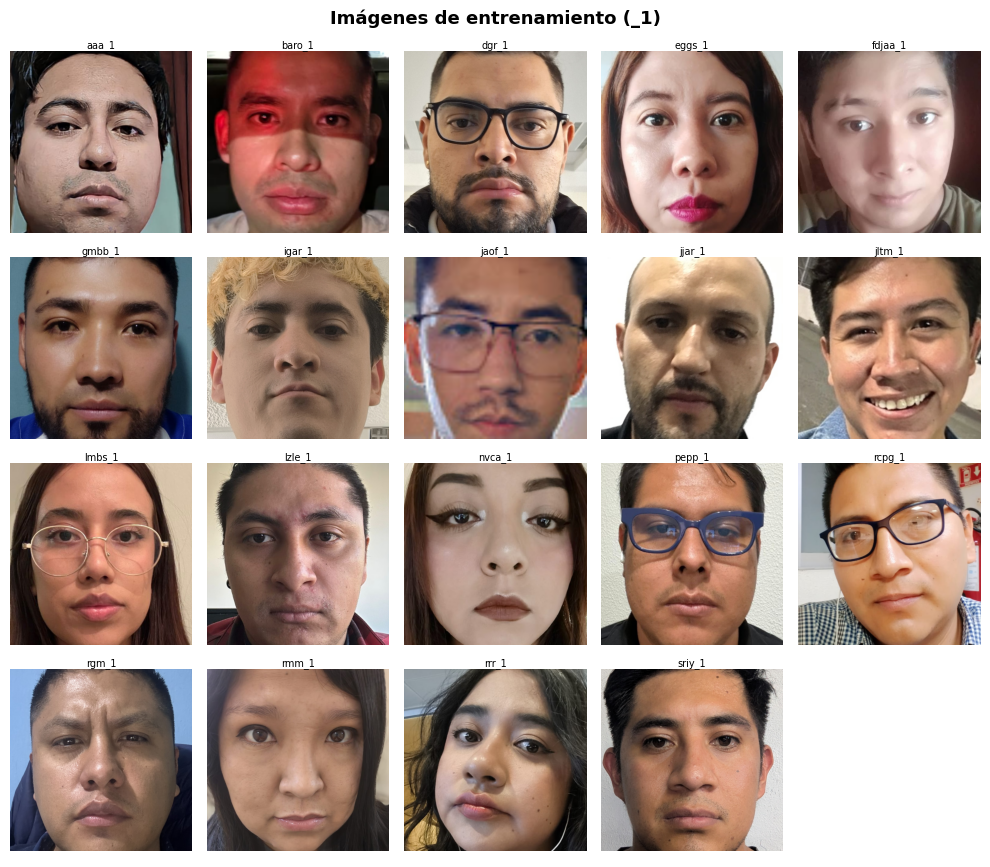

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8 — Verificación visual: grilla de entrenamiento
# ═══════════════════════════════════════════════════════════════
# Importante: antes de entrenar, siempre verifica visualmente que
# las caras se detectaron bien. Si alguna se recortó mal, hay que
# ajustar los parámetros de detectar_y_recortar (escala/vecinos).

mostrar_grilla(X_train, nombres_train, titulo='Imágenes de entrenamiento (_1)')

---
## Sección 4 — KNN: entrenamiento

**¿Qué hace KNN (K-Nearest Neighbors)?**

A diferencia del perceptrón, KNN **no ajusta pesos** durante el entrenamiento.  
Simplemente **memoriza todos los ejemplos**. Al clasificar algo nuevo:

1. Calcula la distancia de ese ejemplo a TODOS los del entrenamiento
2. Encuentra los `k` más cercanos
3. Devuelve la clase más frecuente entre esos `k` vecinos

Con `k=1` → el más cercano gana (funciona bien con pocas imágenes por persona).

```
¿A quién se parece más este rostro?
  distancia(nuevo, persona_A) = 0.23  ← más cercano → predicción: persona_A
  distancia(nuevo, persona_B) = 0.87
  distancia(nuevo, persona_C) = 0.61
```

La "distancia" aquí es **distancia euclidiana entre vectores de píxeles** (p=2).


In [21]:
# ═══════════════════════════════════════════════════════════════
# CELDA 9 — Entrenamiento del clasificador KNN
# ═══════════════════════════════════════════════════════════════

# KNeighborsClassifier — K vecinos más cercanos
# Parámetros:
#   n_neighbors=1 → con 1 imagen por persona, 1 vecino es lo correcto
#                   con más imágenes por persona, prueba k=3 o k=5
#   p=2           → distancia euclidiana (raíz cuadrada de suma de cuadrados)
#                   p=1 → distancia Manhattan (suma de valores absolutos)

clasificador = KNeighborsClassifier(n_neighbors=1, p=2)

# .fit() con KNN no "entrena" en el sentido clásico:
# simplemente almacena X_train y y_train en memoria
# El trabajo real ocurre en .predict()
clasificador.fit(X_train, y_train)

print("KNN entrenado ✅")
print(f"  Imágenes en memoria: {len(X_train)}")
print(f"  Dimensión de cada vector: {X_train.shape[1]} ({TAMANO}×{TAMANO}×3 píxeles)")
print(f"  Clases: {list(range(len(nombres_train)))}")

KNN entrenado ✅
  Imágenes en memoria: 19
  Dimensión de cada vector: 1444908 (694×694×3 píxeles)
  Clases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


---
## Sección 5 — Prueba con 10+ imágenes + tabla de resultados

probar con al menos 10 imágenes
y generar una tabla con imagen, etiqueta predicha, etiqueta real y resultado.


---
### Clasificacor min v1

In [22]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Clasificar todas las imágenes de prueba
# ═══════════════════════════════════════════════════════════════

predicciones = []
resultados   = []

print("Clasificando imágenes de prueba...")
print("═"*65)
print(f"{'#':>3} {'Archivo':<25} {'Real':>5} {'Pred':>5} {'OK':>4}  Características")
print("─"*65)

for i, (vec, etiq_real, nombre, info) in enumerate(zip(X_test, y_test, nombres_test, infos_test)):
    # Predicción: reshape(1,-1) porque predict espera array 2D (batch)
    pred = clasificador.predict(vec.reshape(1, -1))[0]
    predicciones.append(pred)

    ok = '✅' if pred == etiq_real else '❌'

    # Nombre de quién predijo el modelo (basado en nombres de entrenamiento)
    nombre_pred = nombres_train[pred] if pred < len(nombres_train) else '??'
    nombre_real = nombres_train[etiq_real] if etiq_real < len(nombres_train) else '??'

    # Características extraídas de la imagen con cv2
    brillo   = info.get('brillo', '?')
    dims     = info.get('dimensiones', '?')
    n_caras  = info.get('n_rostros', 0)

    print(f"{i:>3} {nombre:<25} {etiq_real:>5} {pred:>5} {ok:>4}  "
          f"dim={dims} brillo={brillo} caras={n_caras}")

    resultados.append({
        'archivo':   nombre,
        'real':      etiq_real,
        'nombre_real': os.path.splitext(nombre_real)[0],
        'pred':      pred,
        'nombre_pred': os.path.splitext(nombre_pred)[0],
        'correcto':  pred == etiq_real,
        'brillo':    brillo,
        'dims':      dims,
    })

print("─"*65)

# Accuracy
correctos = sum(1 for r in resultados if r['correcto'])
acc = correctos / len(resultados) * 100
print(f"\n  Resultado: {correctos}/{len(resultados)} correctos → Accuracy: {acc:.1f}%")

Clasificando imágenes de prueba...
═════════════════════════════════════════════════════════════════
  # Archivo                    Real  Pred   OK  Características
─────────────────────────────────────────────────────────────────


TypeError: '<' not supported between instances of 'numpy.str_' and 'int'

---
### Actualizacion de la ceda de clasificacion para que use los nombres en lugar de los indices

In [28]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Clasificar todas las imágenes de prueba
# ═══════════════════════════════════════════════════════════════
# Ahora y_train e y_test contienen NOMBRES de persona ('aaa','baro',etc.)
# así que aunque falte alguna imagen, las etiquetas siempre coinciden

predicciones = []
resultados   = []

print("Clasificando imágenes de prueba...")
print("═"*65)
print(f"{'#':>3} {'Archivo':<25} {'Real':>10} {'Pred':>10} {'OK':>4}  Características")
print("─"*65)

for i, (vec, etiq_real, nombre, info) in enumerate(zip(X_test, y_test, nombres_test, infos_test)):
    pred = clasificador.predict(vec.reshape(1, -1))[0]   # pred es un string: 'aaa', 'baro', etc.
    predicciones.append(pred)

    ok = '✅' if pred == etiq_real else '❌'

    brillo  = info.get('brillo', '?')
    dims    = info.get('dimensiones', '?')
    n_caras = info.get('n_rostros', 0)

    print(f"{i:>3} {nombre:<25} {etiq_real:>10} {pred:>10} {ok:>4}  "
          f"dim={dims} brillo={brillo}")

    resultados.append({
        'archivo':   nombre,
        'real':      etiq_real,
        'pred':      pred,
        'correcto':  pred == etiq_real,
        'brillo':    brillo,
        'dims':      dims,
        'n_rostros': n_caras,
    })

print("─"*65)
correctos = sum(1 for r in resultados if r['correcto'])
acc = correctos / len(resultados) * 100
print(f"\n  Resultado: {correctos}/{len(resultados)} correctos → Accuracy: {acc:.1f}%")

Clasificando imágenes de prueba...
═════════════════════════════════════════════════════════════════
  # Archivo                         Real       Pred   OK  Características
─────────────────────────────────────────────────────────────────
  0 aaa_2.jpeg                       aaa        aaa    ✅  dim=1200×1599 brillo=94.2
  1 baro_2.jpeg                     baro       baro    ✅  dim=961×1280 brillo=80.1
  2 eggs_2.jpeg                     eggs       eggs    ✅  dim=1200×1600 brillo=91.3
  3 fdjaa_2.jpeg                   fdjaa      fdjaa    ✅  dim=1080×1350 brillo=77.4
  4 fybr_2.jpeg                     fybr       igar    ❌  dim=901×1600 brillo=148.5
  5 gmbb_2.jpeg                     gmbb       gmbb    ✅  dim=1200×1600 brillo=111.3
  6 igar_2.jpg                      igar       igar    ✅  dim=3456×4608 brillo=145.1
  7 jltm_2.jpg                      jltm       jltm    ✅  dim=704×1472 brillo=64.1
  8 lmbs_2.jpeg                     lmbs       lmbs    ✅  dim=1200×1600 brillo=115.8
  

---
### Agregamos detectores auxiliares para caracteristicas (lentes,expresiones,gorras)

In [24]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5b — Detectores auxiliares de características
# ═══════════════════════════════════════════════════════════════
# Haar Cascade no solo detecta caras — también tiene detectores
# entrenados para ojos, lentes y sonrisa.
# La estrategia: primero detectar la cara → luego buscar características
# DENTRO de esa región → menos falsos positivos que en imagen completa.

cascade_ojos_lentes = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye_tree_eyeglasses.xml"
)
cascade_ojos = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)
cascade_sonrisa = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

def analizar_caracteristicas(ruta_imagen):
    """
    Detecta características faciales dentro del rostro ya localizado.
    
    ¿Por qué dentro del rostro y no en toda la imagen?
    Si buscamos lentes en la imagen completa, podría confundirse con
    ventanas, marcos de cuadros, etc. Al recortar solo el rostro
    primero, el detector sabe exactamente dónde buscar.
    
    Regresa un dict con:
        lentes   → bool, si detectó lentes u ojos con montura
        sonrisa  → bool, si detectó sonrisa
        n_ojos   → int, cuántos ojos detectó (referencia)
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return {'detectado': False, 'lentes': False, 'sonrisa': False, 'n_ojos': 0}

    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Paso 1: detectar el rostro
    rostros = face_cascade.detectMultiScale(img_rgb, 1.1, 2)
    if len(rostros) == 0:
        return {'detectado': False, 'lentes': False, 'sonrisa': False, 'n_ojos': 0}

    x, y, w, h = rostros[0]

    # Paso 2: recortar solo la región del rostro en escala de grises
    rostro_gris = img_gris[y:y+h, x:x+w]

    # Paso 3: detectar ojos CON lentes dentro del rostro
    # minNeighbors=5 → necesita 5 rectángulos vecinos para confirmar
    # (más estricto → menos falsos positivos)
    ojos_lentes = cascade_ojos_lentes.detectMultiScale(rostro_gris, 1.1, 5)

    # Paso 4: detectar ojos SIN lentes (referencia)
    ojos_normal = cascade_ojos.detectMultiScale(rostro_gris, 1.1, 5)

    # Paso 5: detectar sonrisa solo en la MITAD INFERIOR del rostro
    # Razón: la nariz o el bigote en la zona superior puede parecer sonrisa
    mitad_inf   = rostro_gris[h//2:, :]
    sonrisas    = cascade_sonrisa.detectMultiScale(mitad_inf, 1.7, 20)

    return {
        'detectado': True,
        'lentes':    len(ojos_lentes) > 0,
        'sonrisa':   len(sonrisas) > 0,
        'n_ojos':    len(ojos_normal),
    }


print("Detectores de características cargados ✅")
print("  • haarcascade_eye_tree_eyeglasses → lentes")
print("  • haarcascade_eye                 → ojos (referencia)")
print("  • haarcascade_smile               → sonrisa")

Detectores de características cargados ✅
  • haarcascade_eye_tree_eyeglasses → lentes
  • haarcascade_eye                 → ojos (referencia)
  • haarcascade_smile               → sonrisa


---
### Tabla para visualizar

KeyError: 'nombre_real'

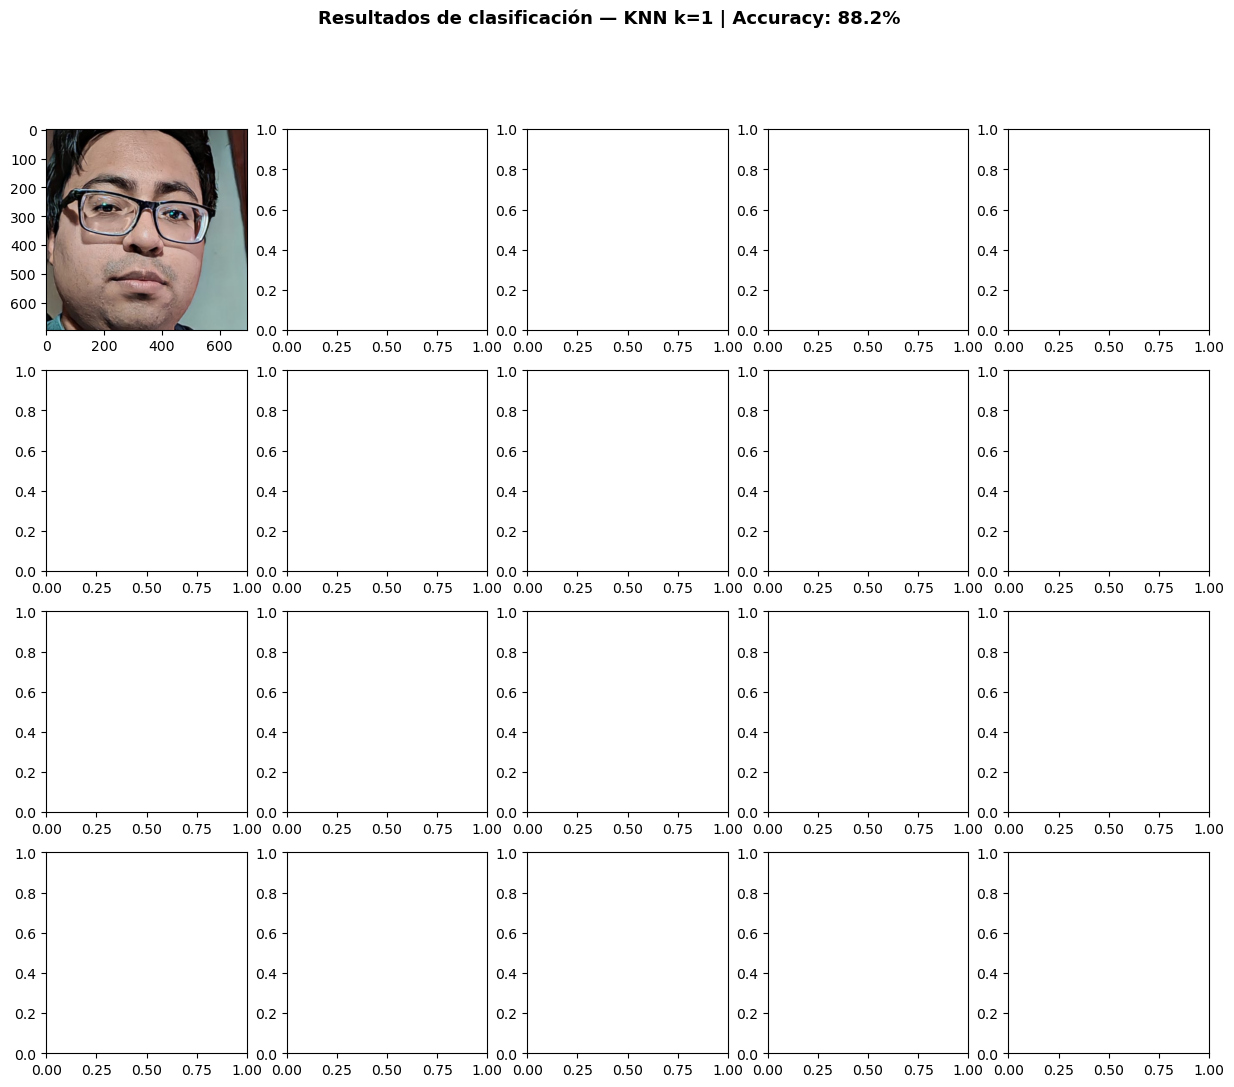

In [25]:
# ═══════════════════════════════════════════════════════════════
# CELDA 11 — Tabla visual con matplotlib
# ═══════════════════════════════════════════════════════════════
# Mostramos la grilla de imágenes de prueba con la predicción encima

fig, axes = plt.subplots(
    nrows=(len(X_test) + 4) // 5,   # filas necesarias
    ncols=5,
    figsize=(15, 3 * ((len(X_test) + 4) // 5))
)
fig.suptitle(f'Resultados de clasificación — KNN k=1 | Accuracy: {acc:.1f}%',
             fontsize=13, fontweight='bold')

axes_flat = np.array(axes).flatten()

for i, (vec, info, res) in enumerate(zip(X_test, infos_test, resultados)):
    img = vec.reshape(TAMANO, TAMANO, 3)
    axes_flat[i].imshow(img)

    color = 'green' if res['correcto'] else 'red'
    titulo = (f"Real: {res['nombre_real'].split('_')[0]}\n"
              f"Pred: {res['nombre_pred'].split('_')[0]}")
    axes_flat[i].set_title(titulo, fontsize=7, color=color, pad=2)

    # Marco de color según correcto/incorrecto
    for spine in axes_flat[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes_flat[i].axis('off')

for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

---
### Tabla final combinada

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELDA 12 — Tabla detallada con características de imagen
# ═══════════════════════════════════════════════════════════════
# Aquí usamos los datos que cv2 nos dio de cada imagen:
# - Dimensiones originales (antes de recortar)
# - Brillo promedio (media de la imagen en escala de grises)
# - Si fue bien identificado o no

print("\n" + "═"*80)
print("  TABLA COMPLETA — Resultados con características de imagen")
print("═"*80)
print(f"{'#':>3} {'Archivo':<22} {'Real':<12} {'Predicho':<12} {'Dims':>8} "
      f"{'Brillo':>7} {'OK':>4}")
print("─"*80)

for i, res in enumerate(resultados):
    ok = '✅' if res['correcto'] else '❌'
    print(f"{i:>3} {res['archivo']:<22} {res['nombre_real']:<12} "
          f"{res['nombre_pred']:<12} {res['dims']:>8} {res['brillo']:>7} {ok:>4}")

print("─"*80)
print(f"  ACCURACY: {correctos}/{len(resultados)} = {acc:.1f}%")
print()
print("Nota sobre el brillo:")
print("  Brillo bajo (<80)   → imagen oscura → más difícil de detectar")
print("  Brillo alto (>180)  → imagen sobreexpuesta → puede perder detalle")
print("  Brillo ideal: 100-150 → buena iluminación")


════════════════════════════════════════════════════════════════════════════════
  TABLA COMPLETA — Resultados con características de imagen
════════════════════════════════════════════════════════════════════════════════
  # Archivo                Real         Predicho         Dims  Brillo   OK
────────────────────────────────────────────────────────────────────────────────
  0 aaa_2.jpeg             aaa_1        aaa_1        1200×1599    94.2    ✅
  1 baro_2.jpeg            baro_1       baro_1       961×1280    80.1    ✅
  2 dgr_2.jpg              eggs_1       eggs_1       2448×3264   137.2    ✅
  3 eggs_2.jpeg            fdjaa_1      fdjaa_1      1200×1600    91.3    ✅
  4 fdjaa_2.jpeg           fybr_1       igar_1       1080×1350    77.4    ❌
  5 fybr_2.jpeg            gmbb_1       gmbb_1       901×1600   148.5    ✅
  6 gmbb_2.jpeg            igar_1       igar_1       1200×1600   111.3    ✅
  7 igar_2.jpg             jltm_1       jltm_1       3456×4608   145.1    ✅
  8 jaof_2.jpg 

---
### Tabla completa v2

In [29]:
# ═══════════════════════════════════════════════════════════════
# CELDA 12 — Tabla completa: resultado + características cv2
# ═══════════════════════════════════════════════════════════════
# Aquí combinamos todo:
#   - Si el KNN acertó o no
#   - Características físicas detectadas por cv2
#   - Datos de la imagen (brillo, dimensiones)
#
# ¿Para qué sirve esto?
#   Podemos cruzar los datos y ver si hay PATRONES en los errores.
#   Ejemplo: ¿Todos los que fallaron traen lentes? ¿Tienen brillo bajo?
#   Esto ayuda a diagnosticar las limitaciones del modelo.

# Construir lista de rutas de test para analizar características
archivos_test_rutas = sorted(set(
    os.path.normcase(a)
    for ext in ('jpg','jpeg','JPG','JPEG','png')
    for a in glob.glob(RUTA + f'*_2.{ext}')
))

print("═"*85)
print("  TABLA COMPLETA — Clasificación + Características detectadas con cv2")
print("═"*85)
print(f"{'#':>3} {'Archivo':<22} {'Real':>8} {'Pred':>8} {'Lentes':>7} "
      f"{'Sonrisa':>8} {'Brillo':>7} {'OK':>4}")
print("─"*85)

for i, res in enumerate(resultados):
    # Buscar la ruta completa de este archivo de test
    ruta_test = next(
        (r for r in archivos_test_rutas if os.path.basename(r) == res['archivo']),
        None
    )

    if ruta_test:
        caract = analizar_caracteristicas(ruta_test)
        lentes  = '🕶️ Sí' if caract.get('lentes')  else 'No'
        sonrisa = '😊 Sí' if caract.get('sonrisa') else 'No'
    else:
        lentes = sonrisa = 'n/a'

    ok = '✅' if res['correcto'] else '❌'

    print(f"{i:>3} {res['archivo']:<22} {res['real']:>8} {res['pred']:>8} "
          f"{lentes:>7} {sonrisa:>8} {res['brillo']:>7} {ok:>4}")

    # Si falló, explicamos posible causa
    if not res['correcto']:
        causas = []
        if caract.get('lentes'):
            causas.append("lentes dificultan detección")
        if res['brillo'] < 80:
            causas.append("imagen oscura")
        if res['n_rostros'] == 0:
            causas.append("rostro no detectado")
        if causas:
            print(f"    ↳ Posibles causas: {', '.join(causas)}")

print("─"*85)
print(f"  ACCURACY: {correctos}/{len(resultados)} = {acc:.1f}%")
print()

# Análisis de patrones en errores
errores = [r for r in resultados if not r['correcto']]
if errores:
    print("Análisis de errores:")
    print(f"  Total de errores: {len(errores)}")
    for e in errores:
        print(f"  • {e['archivo']}: era '{e['real']}', predijo '{e['pred']}'")
    print()
    print("¿Qué podríamos mejorar?")
    print("  → Aumentar el tamaño de la imagen (TAMANO=200 en lugar de 100)")
    print("  → Probar con otro cascade: haarcascade_frontalface_default.xml")
    print("  → Normalizar el brillo antes de comparar (equalizeHist)")
    print("  → Agregar más fotos de entrenamiento por persona (k=3 requiere 3+)")

═════════════════════════════════════════════════════════════════════════════════════
  TABLA COMPLETA — Clasificación + Características detectadas con cv2
═════════════════════════════════════════════════════════════════════════════════════
  # Archivo                    Real     Pred  Lentes  Sonrisa  Brillo   OK
─────────────────────────────────────────────────────────────────────────────────────
  0 aaa_2.jpeg                  aaa      aaa   🕶️ Sí     😊 Sí    94.2    ✅
  1 baro_2.jpeg                baro     baro      No       No    80.1    ✅
  2 eggs_2.jpeg                eggs     eggs   🕶️ Sí     😊 Sí    91.3    ✅
  3 fdjaa_2.jpeg              fdjaa    fdjaa   🕶️ Sí     😊 Sí    77.4    ✅
  4 fybr_2.jpeg                fybr     igar   🕶️ Sí       No   148.5    ❌
    ↳ Posibles causas: lentes dificultan detección
  5 gmbb_2.jpeg                gmbb     gmbb   🕶️ Sí     😊 Sí   111.3    ✅
  6 igar_2.jpg                 igar     igar   🕶️ Sí       No   145.1    ✅
  7 jltm_2.jpg       

In [27]:
# ═══════════════════════════════════════════════════════════════
# CELDA 13 — Experimentos: efecto de k y métrica de distancia
# ═══════════════════════════════════════════════════════════════
# nos pide probar cambiando parámetros del clasificador.
# Aquí comparamos varias configuraciones de KNN.

configs_knn = [
    # (n_neighbors, p, descripción)
    (1, 2, 'k=1, distancia Euclidiana'),
    (1, 1, 'k=1, distancia Manhattan'),
    (3, 2, 'k=3, distancia Euclidiana'),
    (5, 2, 'k=5, distancia Euclidiana'),
]

print("Comparando configuraciones de KNN:")
print("─"*55)
print(f"{'Config':<35} {'Correctos':>9} {'Accuracy':>9}")
print("─"*55)

for k, p, desc in configs_knn:
    if len(X_train) >= k:   # necesitamos al menos k ejemplos para probar
        modelo_exp = KNeighborsClassifier(n_neighbors=k, p=p)
        modelo_exp.fit(X_train, y_train)
        preds_exp = modelo_exp.predict(X_test)
        acc_exp   = accuracy_score(y_test, preds_exp)
        n_ok      = int(acc_exp * len(y_test))
        print(f"  {desc:<33} {n_ok:>4}/{len(y_test):<4}  {acc_exp*100:>7.1f}%")
    else:
        print(f"  {desc:<33}  (necesita {k} ejemplos, tenemos {len(X_train)})")

print()
print("Observa:")
print("  k=1 funciona bien cuando tienes pocas imágenes por persona")
print("  k=3 o k=5 son mejores cuando tienes varias fotos por persona")

Comparando configuraciones de KNN:
───────────────────────────────────────────────────────
Config                              Correctos  Accuracy
───────────────────────────────────────────────────────
  k=1, distancia Euclidiana           15/17       88.2%
  k=1, distancia Manhattan            15/17       88.2%
  k=3, distancia Euclidiana            5/17       29.4%
  k=5, distancia Euclidiana            3/17       17.6%

Observa:
  k=1 funciona bien cuando tienes pocas imágenes por persona
  k=3 o k=5 son mejores cuando tienes varias fotos por persona


###  modos de lectura de cv2
- `cv2.imread(ruta)` → lee en BGR con 3 canales (color)
- `cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)` → lee en escala de grises (1 canal)
- `cv2.imread(ruta, cv2.IMREAD_UNCHANGED)` → lee tal cual incluyendo canal alpha (4ch)
- `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` → convierte BGR→RGB para matplotlib
- `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` → convierte a escala de grises
